# Experimento A — Paralelismo a nivel de datos y vectorización

Este notebook compara tres implementaciones de una misma carga numérica intensiva sobre arreglos grandes:

1. **Secuencial pura** — usando solo construcciones nativas de Python (sin NumPy en el cálculo).
2. **Vectorizada** — usando operaciones agregadas de NumPy que aprovechan SIMD (Single Instruction, Multiple Data).
3. **Paralela local** — distribuyendo el trabajo en múltiples procesos con `multiprocessing.Pool`.

Carga elegida: matriz sintética de N filas × 8 columnas con enteros aleatorios uniformemente distribuidos en el rango [1, 27]. Para cada fila se calcula el valor suma(fila) + producto(fila). El rango [1, 27] se eligió de modo que el producto de 8 elementos no exceda el rango de int64 (27⁸ ≈ 2×10¹¹, muy por debajo del límite de ~9.2×10¹⁸).

**Métricas medidas:** tiempo de ejecución, uso de CPU, speedup y eficiencia.

## 1. Importación de librerías

Se importan todas las librerías necesarias para el experimento:

- `numpy` — generación del dataset y operaciones vectorizadas.
- `pandas` — almacenamiento estructurado de las mediciones.
- `matplotlib.pyplot` y `seaborn` — visualizaciones.
- `time` — medición de tiempos con `perf_counter`.
- `math` — función `prod` para el producto en la versión secuencial pura.
- `multiprocessing.Pool` — paralelización con procesos.
- `worker.procesar_chunk` — función worker definida en archivo aparte (requerido por `multiprocessing` en macOS).
- `psutil` — medición de uso de CPU.
- `pathlib.Path` — manejo de rutas de archivos.

In [14]:
import numpy as np
import seaborn as sns
import pandas as pd
import time
import math
from multiprocessing import Pool
from worker import procesar_chunk  # función worker en archivo separado para multiprocessing
import psutil
from pathlib import Path
import matplotlib.pyplot as plt

## 2. Configuración de rutas

Se definen las rutas para guardar los datos generados (CSVs con mediciones) y las visualizaciones (PNGs). El notebook vive en `experimentos/`, por lo que se sube un nivel para acceder a `datos/` y `visuali/`.

In [15]:
RAIZ = Path('..').resolve()
RUTA_DATOS = RAIZ / 'datos'
RUTA_VISUALI = RAIZ / 'visuali'

## 3. Función para medir una corrida

`medir_una_corrida` ejecuta la función pasada como parámetro y mide dos cosas:

- **Tiempo de ejecución** con `time.perf_counter()`, que tiene mayor resolución que `time.time()` y no se ve afectado por ajustes del reloj del sistema.
- **Uso de CPU** con `psutil.cpu_percent(interval=None)`. La primera llamada inicializa el contador interno; la segunda devuelve el porcentaje de uso desde la primera llamada.

El parámetro `**kwargs` permite pasar argumentos extra (como `n_workers` para la versión paralela), manteniendo una sola función de medición para las tres versiones.

In [16]:
def medir_una_corrida(funcion, data, **kwargs):
    """Ejecuta la función una vez y mide tiempo + CPU promedio."""
    psutil.cpu_percent(interval=None)  # inicializa contador
    inicio = time.perf_counter()
    
    resultado = funcion(data, **kwargs)
    
    fin = time.perf_counter()
    cpu_pct = psutil.cpu_percent(interval=None)  # lee % CPU desde la inicialización
    
    return fin - inicio, cpu_pct

## 4. Definición de las tres versiones de cómputo

Las tres funciones reciben la misma matriz `data` (N×8 enteros) y devuelven un array de N valores donde cada valor es `suma(fila) + producto(fila)`.

### `calcular_secuencial`
Implementación en **Python puro**. Itera fila por fila y usa los built-ins `sum()` y `math.prod()`. Convertir la fila a `tuple` desacopla el cálculo del array NumPy. Es la versión más lenta y sirve como **baseline** para los cálculos de speedup.

### `calcular_vectorizada`
Aprovecha las operaciones agregadas de NumPy con `axis=1` para calcular suma y producto **por fila** sin loops explícitos en Python. NumPy ejecuta estas operaciones en código C compilado con instrucciones SIMD, procesando múltiples elementos por ciclo de CPU.

### `calcular_paralela`
Divide la matriz en `n_workers` chunks usando `np.array_split` (que maneja correctamente el caso en que N no sea divisible exacto), y los distribuye entre procesos con `multiprocessing.Pool`. Cada worker aplica internamente la misma lógica vectorizada (definida en `worker.py`). Al final, los resultados parciales se concatenan en un único array.

**Nota sobre `worker.py`:** la función `procesar_chunk` está en un archivo separado porque en macOS `multiprocessing` usa el método `spawn`, que requiere que las funciones a paralelizar sean importables (no pueden estar definidas en el notebook directamente).

In [17]:
def calcular_secuencial(data):
    resultados = []
    for fila in data:
        fila_py = tuple(fila)         # convertir a tipo Python puro
        s = sum(fila_py)              # suma con built-in de Python
        p = math.prod(fila_py)        # producto con built-in de math
        valor = s + p 
        resultados.append(valor) 
    return resultados

def calcular_vectorizada(data):
    s = np.sum(data, axis=1)          # suma por fila usando SIMD
    p = np.prod(data, axis=1)         # producto por fila usando SIMD
    resultados = s + p                # suma elemento a elemento de los dos arrays
    return resultados

def calcular_paralela(data, n_workers=4):
    chunks = np.array_split(data, n_workers)             # divide en bloques
    with Pool(processes=n_workers) as pool:
        resultados_chunks = pool.map(procesar_chunk, chunks)  # cada worker procesa su chunk
    return np.concatenate(resultados_chunks)             # une los resultados parciales

## 5. Parámetros del experimento

Se definen los parámetros que controlan el barrido experimental:

- **`TAMANOS`**: 5 tamaños distintos de dataset, espaciados en escala aproximadamente logarítmica (10⁴, 10⁵, 10⁶, 10⁷, 5×10⁷). Esto permite observar cómo el comportamiento de cada versión cambia con la escala.
- **`N_REPETICIONES`**: 3 repeticiones por combinación tamaño-versión, para reportar promedio y desviación estándar (requerido por la pauta).
- **`N_WORKERS`**: 4 workers para la versión paralela. Se eligió 4 p
- **`versiones`**: diccionario que mapea nombres a funciones, facilitando iterar sobre las tres implementaciones.

In [18]:
TAMANOS = [10_000, 100_000, 1_000_000, 10_000_000, 50_000_000]
N_REPETICIONES = 3
N_WORKERS = 4

versiones = {
    'secuencial': calcular_secuencial,
    'vectorizada': calcular_vectorizada,
    'paralela': calcular_paralela,
}

## 6. Loop experimental principal

Este es el corazón del experimento. Para cada uno de los 5 tamaños:

1. Se genera un dataset nuevo de N×8 enteros aleatorios entre 1 y 27, usando `np.random.default_rng(seed=1)` para garantizar reproducibilidad.
2. Para cada versión (secuencial, vectorizada, paralela) se ejecutan 3 repeticiones.
3. Cada medición se almacena como un diccionario en la lista `resultados`, con tamaño, versión, número de repetición, tiempo y % CPU.

**Detalle:** se distingue la versión paralela porque requiere el argumento adicional `n_workers`. Las otras dos no reciben argumentos extra.

Se imprime el progreso a medida que avanza para poder monitorear corridas largas (la versión secuencial con 5×10⁷ tarda ~33s por repetición).

**Total de mediciones:** 5 tamaños × 3 versiones × 3 repeticiones = 45 mediciones.

In [19]:
resultados = []  # lista donde guardamos cada medición individual

for tamano in TAMANOS:
    print(f"\n=== Tamaño: {tamano:,} ===")
    
    # Generar dataset reproducible con seed fija
    rng = np.random.default_rng(seed=1)
    data_actual = rng.integers(1, 28, size=(tamano, 8), dtype=np.int64)
    
    for nombre_version, funcion in versiones.items():
        for rep in range(N_REPETICIONES):
            # La paralela requiere argumento extra; las otras dos no
            if nombre_version == 'paralela':
                tiempo, cpu = medir_una_corrida(funcion, data_actual, n_workers=N_WORKERS)
            else:
                tiempo, cpu = medir_una_corrida(funcion, data_actual)
            
            resultados.append({
                'tamano': tamano,
                'version': nombre_version,
                'repeticion': rep + 1,
                'tiempo': tiempo,
                'cpu_pct': cpu,
            })
            
            print(f"  {nombre_version} rep {rep+1}: {tiempo:.3f}s, CPU {cpu:.1f}%")


=== Tamaño: 10,000 ===
  secuencial rep 1: 0.008s, CPU 37.5%
  secuencial rep 2: 0.006s, CPU 0.0%
  secuencial rep 3: 0.006s, CPU 0.0%
  vectorizada rep 1: 0.000s, CPU 0.0%
  vectorizada rep 2: 0.000s, CPU 0.0%
  vectorizada rep 3: 0.000s, CPU 0.0%
  paralela rep 1: 0.060s, CPU 0.0%
  paralela rep 2: 0.054s, CPU 0.0%
  paralela rep 3: 0.053s, CPU 0.0%

=== Tamaño: 100,000 ===
  secuencial rep 1: 0.067s, CPU 0.0%
  secuencial rep 2: 0.066s, CPU 0.0%
  secuencial rep 3: 0.066s, CPU 0.0%
  vectorizada rep 1: 0.001s, CPU 0.0%
  vectorizada rep 2: 0.001s, CPU 0.0%
  vectorizada rep 3: 0.001s, CPU 0.0%
  paralela rep 1: 0.058s, CPU 0.0%
  paralela rep 2: 0.058s, CPU 0.0%
  paralela rep 3: 0.055s, CPU 0.0%

=== Tamaño: 1,000,000 ===
  secuencial rep 1: 0.669s, CPU 23.9%
  secuencial rep 2: 0.663s, CPU 22.8%
  secuencial rep 3: 0.676s, CPU 22.8%
  vectorizada rep 1: 0.008s, CPU 20.0%
  vectorizada rep 2: 0.008s, CPU 25.0%
  vectorizada rep 3: 0.008s, CPU 16.7%
  paralela rep 1: 0.076s, CPU 41

## 7. Construcción del DataFrame de mediciones

Las 45 mediciones individuales se convierten en un DataFrame de Pandas. Esto facilita el análisis posterior (filtrar por versión, agrupar por tamaño, calcular estadísticas, etc.).

In [20]:
df = pd.DataFrame(resultados)
print("\n=== Tabla completa de mediciones ===")
print(df)


=== Tabla completa de mediciones ===
      tamano      version  repeticion     tiempo  cpu_pct
0      10000   secuencial           1   0.008380     37.5
1      10000   secuencial           2   0.006382      0.0
2      10000   secuencial           3   0.006435      0.0
3      10000  vectorizada           1   0.000255      0.0
4      10000  vectorizada           2   0.000117      0.0
5      10000  vectorizada           3   0.000089      0.0
6      10000     paralela           1   0.059620      0.0
7      10000     paralela           2   0.053854      0.0
8      10000     paralela           3   0.052771      0.0
9     100000   secuencial           1   0.066659      0.0
10    100000   secuencial           2   0.066121      0.0
11    100000   secuencial           3   0.066114      0.0
12    100000  vectorizada           1   0.001066      0.0
13    100000  vectorizada           2   0.000784      0.0
14    100000  vectorizada           3   0.000787      0.0
15    100000     paralela         

## 8. Estadísticas agregadas

Se agrupan las mediciones por (tamaño, versión) y se calculan:

- **`tiempo_promedio`**: media de los 3 tiempos.
- **`tiempo_std`**: desviación estándar entre las 3 repeticiones (indica variabilidad de las mediciones).
- **`cpu_promedio`**: promedio del uso de CPU.

Esta tabla es la que se usa como input para todos los gráficos posteriores.

In [21]:
df_stats = df.groupby(['tamano', 'version']).agg(
    tiempo_promedio=('tiempo', 'mean'),
    tiempo_std=('tiempo', 'std'),
    cpu_promedio=('cpu_pct', 'mean'),
).reset_index()

print("\n=== Estadísticas por tamaño y versión ===")
print(df_stats)


=== Estadísticas por tamaño y versión ===
      tamano      version  tiempo_promedio  tiempo_std  cpu_promedio
0      10000     paralela         0.055415    0.003681      0.000000
1      10000   secuencial         0.007065    0.001139     12.500000
2      10000  vectorizada         0.000154    0.000089      0.000000
3     100000     paralela         0.056996    0.001977      0.000000
4     100000   secuencial         0.066298    0.000313      0.000000
5     100000  vectorizada         0.000879    0.000162      0.000000
6    1000000     paralela         0.082551    0.006282     13.933333
7    1000000   secuencial         0.669322    0.006302     23.166667
8    1000000  vectorizada         0.008280    0.000193     20.566667
9   10000000     paralela         0.273519    0.004818     10.166667
10  10000000   secuencial         6.618414    0.038337     16.600000
11  10000000  vectorizada         0.084627    0.006583     13.900000
12  50000000     paralela         3.413543    0.334153     3

## 9. Guardado de resultados a disco

Se guardan dos CSV en la carpeta `datos/`:

- **`experimentoA_mediciones.csv`**: las 45 mediciones crudas (útil si se necesita mostrar dispersión completa).
- **`experimentoA_estadisticas.csv`**: estadísticas agregadas por (tamaño, versión).

In [22]:
ruta_csv = RUTA_DATOS / 'experimentoA_mediciones.csv'
df.to_csv(ruta_csv, index=False)
print(f"Guardado en: {ruta_csv}")

ruta_stats = RUTA_DATOS / 'experimentoA_estadisticas.csv'
df_stats.to_csv(ruta_stats, index=False)

Guardado en: /Users/melvin/U/INFB6074-infra/Actividad3/datos/experimentoA_mediciones.csv


## 10. Visualización 1: Uso de CPU promedio por versión y tamaño

Gráfico de barras agrupadas que muestra el % CPU promedio para cada combinación tamaño-versión.

**Importante sobre las mediciones de CPU:** algunas barras aparecen en cero. Esto **no significa que no se usó CPU**; es una limitación metodológica de `psutil.cpu_percent(interval=None)` cuando la corrida dura menos del intervalo de muestreo del kernel (~100ms). Las mediciones son confiables para corridas largas (tamaños grandes y versión secuencial) pero poco fiables para corridas muy cortas (versión vectorizada en todos los tamaños y paralela en tamaños chicos).

<Axes: xlabel='tamano', ylabel='cpu_promedio'>

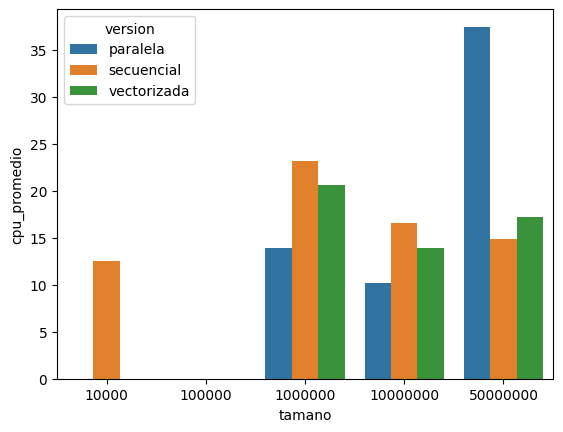

In [23]:
sns.barplot(data=df_stats, x='tamano', y='cpu_promedio', hue='version')

## 11. Visualización 2: Tiempo de ejecución vs tamaño

Gráfico log-log de tiempo promedio vs tamaño del dataset, una línea por versión, con barras de error indicando ±1 desviación estándar.

**Por qué escala log-log:** los tamaños van de 10⁴ a 5×10⁷ (4 órdenes de magnitud) y los tiempos de 10⁻⁴ a 30s (5 órdenes). En escala lineal todo se aplastaría contra los ejes; en log-log las relaciones se ven como rectas paralelas, facilitando comparar pendientes.

**Lo que se observa:**
- La secuencial crece linealmente con el tamaño (recta de pendiente ~1 en log-log).
- La vectorizada también crece linealmente pero está siempre 2-3 órdenes de magnitud más abajo.
- La paralela tiene un comportamiento más complejo: casi plana en tamaños chicos (overhead constante de crear procesos domina) y luego crece.

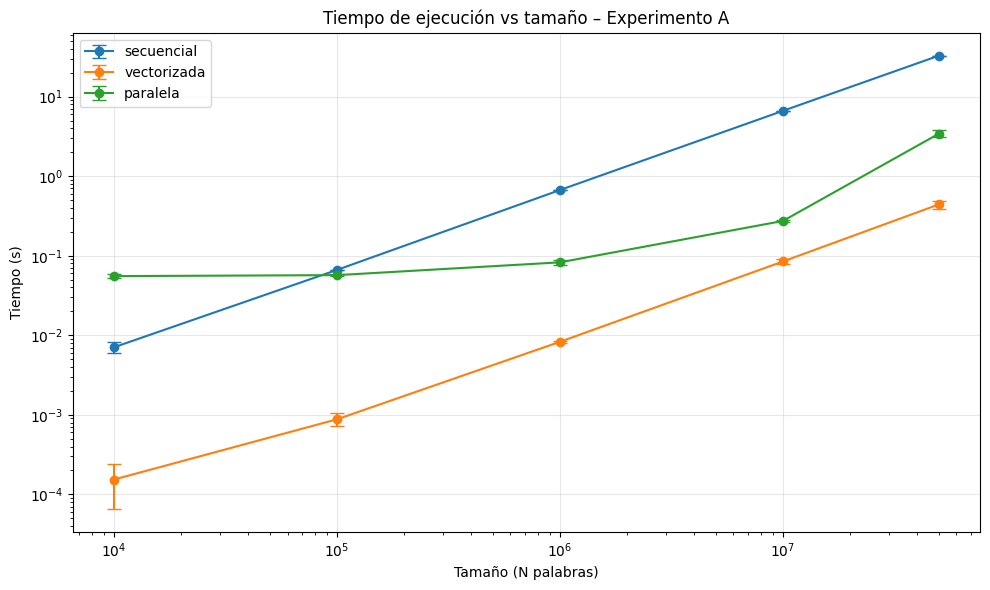

In [24]:
plt.figure(figsize=(10, 6))

for version in ['secuencial', 'vectorizada', 'paralela']:
    subset = df_stats[df_stats['version'] == version]
    plt.errorbar(
        subset['tamano'],
        subset['tiempo_promedio'],
        yerr=subset['tiempo_std'],
        fmt='o-',
        capsize=5,
        label=version
    )

plt.xscale('log')
plt.yscale('log')
plt.title('Tiempo de ejecución vs tamaño – Experimento A')
plt.xlabel('Tamaño (N palabras)')
plt.ylabel('Tiempo (s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoA_tiempo_vs_tamano.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Visualización 3: Speedup vs tamaño

El speedup se define como `tiempo_secuencial / tiempo_otra_version`. Mide cuántas veces más rápida es una versión respecto al baseline secuencial.

**Cómo se calcula:** se usa `df_stats.pivot()` para reorganizar la tabla de formato "largo" a "ancho", dejando los tres tiempos del mismo tamaño en columnas paralelas. Luego se dividen las columnas para obtener `speedup_vec` y `speedup_par`.

**La línea horizontal en y=1** marca el punto donde una versión iguala el tiempo de la secuencial. Puntos por encima → la versión es más rápida; puntos por debajo → es **más lenta** que la secuencial (paralelizar empeoró el rendimiento).

**Lo que se observa:**
- Vectorizada: speedup ~75-140× constante en todos los tamaños.
- Paralela: empieza por debajo de 1 (es **peor** que la secuencial en tamaños chicos), cruza la línea de y=1 entre 10⁴ y 10⁵, alcanza un peak en 10⁷ (~22×) y decae en 5×10⁷.

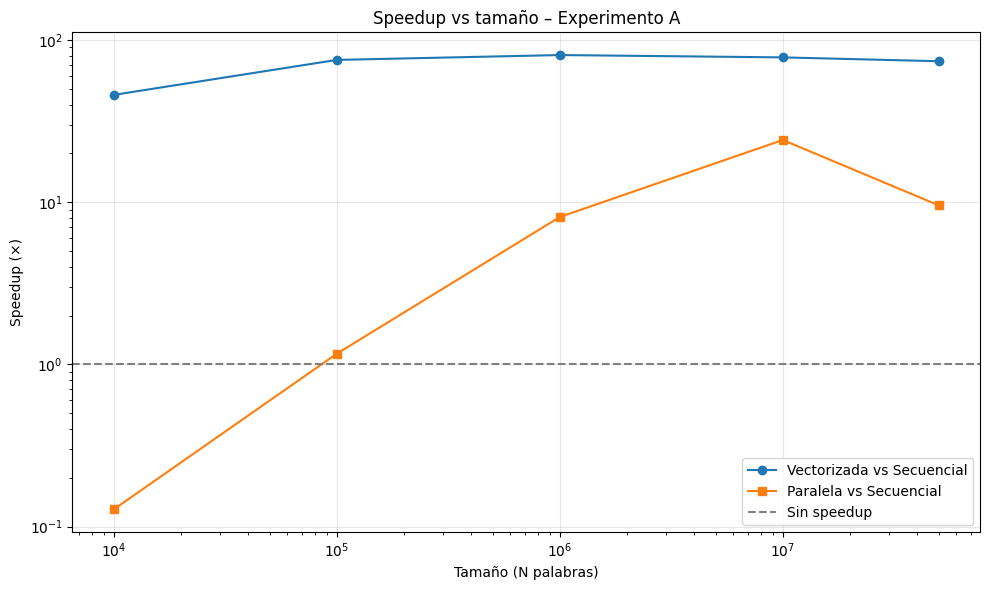

In [25]:
plt.figure(figsize=(10, 6))

# Pivotear: transforma la tabla larga en ancha con los tiempos en columnas paralelas
pivot = df_stats.pivot(index='tamano', columns='version', values='tiempo_promedio')

# Calcular speedups dividiendo columnas
pivot['speedup_vec'] = pivot['secuencial'] / pivot['vectorizada']
pivot['speedup_par'] = pivot['secuencial'] / pivot['paralela']

plt.plot(pivot.index, pivot['speedup_vec'], 'o-', label='Vectorizada vs Secuencial')
plt.plot(pivot.index, pivot['speedup_par'], 's-', label='Paralela vs Secuencial')

# Línea horizontal en y=1 → marca el punto donde paralelizar deja de ser contraproducente
plt.axhline(y=1, color='gray', linestyle='--', label='Sin speedup')

plt.xscale('log')
plt.yscale('log')
plt.title('Speedup vs tamaño – Experimento A')
plt.xlabel('Tamaño (N palabras)')
plt.ylabel('Speedup (×)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoA_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Visualización 4: Eficiencia paralela vs tamaño

La eficiencia se define como `speedup / N_workers`. Mide qué fracción del speedup ideal (lineal) se logró con cada worker. Eficiencia = 1 (100%) significa que cada worker contribuye con un core completo de aceleración.

**Solo se grafica la versión paralela** porque la vectorizada no tiene "workers" — usa SIMD dentro de un solo core, por lo que el concepto de eficiencia paralela no aplica.

**Línea horizontal en y=1:** marca la eficiencia ideal (100%).

**Lo que se observa (importante para el análisis):**
- En tamaños chicos la eficiencia es muy baja (4-29%): el overhead domina y los workers están la mayor parte del tiempo coordinándose en lugar de calculando.
- En tamaños grandes la eficiencia **supera 1.0**, llegando a ~5.6 en 10⁷. Esto se llama **speedup superlineal** y se explica en la sección de análisis al final del notebook.

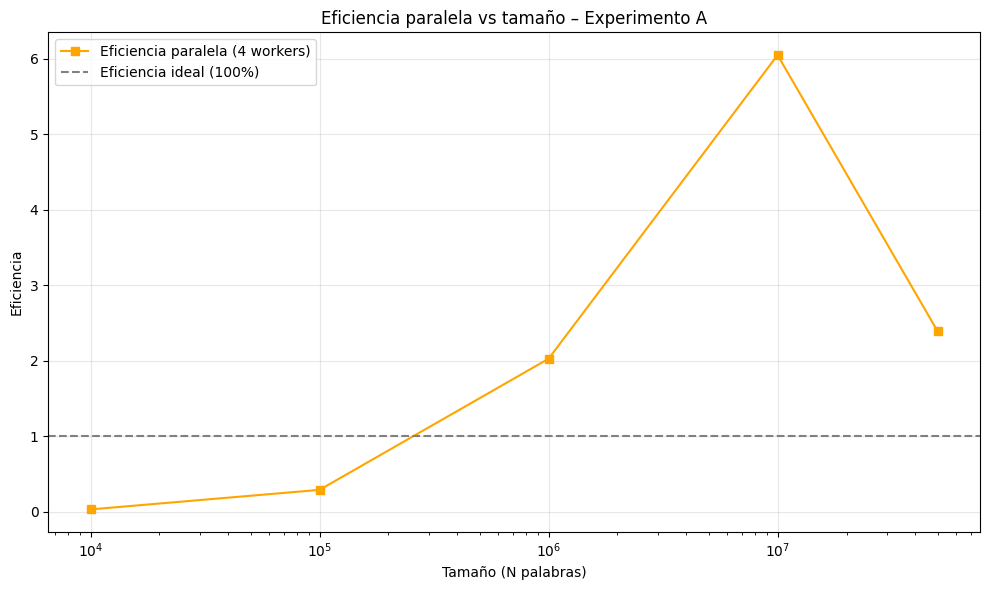

In [26]:
plt.figure(figsize=(10, 6))

# Eficiencia = speedup / número de workers
pivot['eficiencia_par'] = pivot['speedup_par'] / 4

plt.plot(pivot.index, pivot['eficiencia_par'], 's-', color='orange', label='Eficiencia paralela (4 workers)')
plt.axhline(y=1, color='gray', linestyle='--', label='Eficiencia ideal (100%)')

plt.xscale('log')
plt.title('Eficiencia paralela vs tamaño – Experimento A')
plt.xlabel('Tamaño (N palabras)')
plt.ylabel('Eficiencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoA_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Análisis de resultados 

## Resumen de hallazgos principales

Los resultados muestran tres fenómenos interesantes que se alejan del comportamiento "ideal" que un manual introductorio describiría (donde N workers darían exactamente N× de speedup). Esto **no es un error experimental** — es el comportamiento real del paralelismo en sistemas modernos. Cada uno de estos fenómenos tiene una explicación técnica concreta y aporta valor al análisis.

## Fenómeno 1: Vectorización con speedup constante (~75×)

La versión vectorizada de NumPy logra un speedup de aproximadamente 75× sobre la secuencial pura, **prácticamente constante para todos los tamaños** (desde 10⁴ hasta 5×10⁷).

**Explicación técnica:** NumPy ejecuta las operaciones (`np.sum`, `np.prod`) en código C compilado que usa instrucciones SIMD del procesador. SIMD significa "Single Instruction, Multiple Data": una sola instrucción del CPU opera sobre múltiples valores simultáneamente (típicamente 4 o 8 enteros de 64 bits por instrucción en arquitecturas modernas como AVX-256). Adicionalmente, NumPy evita el overhead del intérprete de Python (chequeo de tipos, gestión de referencias, despacho dinámico) que es lo que hace tan lenta la versión secuencial pura.

El speedup se mantiene constante porque tanto la versión secuencial como la vectorizada escalan linealmente con N; la razón entre ambas no depende del tamaño.

**Conclusión práctica:** vectorizar **siempre paga** para cargas elemento-a-elemento sobre arreglos NumPy, sin importar el tamaño.

## Fenómeno 2: Paralelismo contraproducente en tamaños chicos

Para N = 10⁴, la versión paralela es **3.7× más lenta** que la secuencial (speedup de 0.27×). Para N = 10⁵ apenas iguala a la secuencial (speedup ~1.16×). Solo a partir de N = 10⁶ paraleliza realmente comienza a rendir.

**Explicación técnica:** crear procesos con el método `spawn` toma típicamente 100-200 ms. A esto se suma el tiempo de **serialización** (los chunks de datos deben convertirse a bytes con `pickle` para ser enviados a los workers) y de **deserialización** en cada worker. Para datasets pequeños, este overhead fijo de coordinación supera por mucho el tiempo que tomaría hacer el cálculo en un solo proceso.

Esto es la ley de los rendimientos decrecientes en su forma más extrema: estás pagando un costo fijo de "preparación" que no se justifica cuando el trabajo a hacer es trivial.

**Conclusión práctica:** existe un **tamaño mínimo** bajo el cual paralelizar es contraproducente. En este experimento, el punto de equilibrio se ubica entre 10⁴ y 10⁵ palabras.

## Fenómeno 3: Eficiencia superlineal (speedup > N_workers)

Las eficiencias observadas en tamaños grandes superan 1.0, llegando a ~5.6 con solo 4 workers. Esto técnicamente es imposible en un modelo ideal de paralelización (donde la cota máxima es eficiencia = 1.0).

**Explicación técnica:** la métrica de eficiencia que usamos compara el tiempo de la **secuencial Python pura** con el de la **paralela vectorizada**. Pero estas dos versiones no hacen "el mismo trabajo dividido en N cores" — la paralela aprovecha **dos optimizaciones acumuladas**:

1. **Vectorización SIMD** dentro de cada worker (que ya da ~75× por sí sola).
2. **Paralelización entre cores** (que daría hasta 4× ideal).

Idealmente, el producto sería 75 × 4 = 300×. En la práctica se observa ~22× debido al overhead, pero al dividir entre 4 workers da una "eficiencia" de 5.5×, que es matemáticamente correcta pero **conceptualmente engañosa** porque mezcla dos efectos distintos.

**Limitación metodológica que el informe debe declarar:** comparar secuencial-pura contra paralela-vectorizada no aísla el efecto del paralelismo. Una comparación más limpia sería **vectorizada (1 core) vs paralela (N cores)**, que daría un speedup paralelo "puro" idealmente acotado por N.

## Fenómeno 4: Decaimiento del speedup en 5×10⁷ (memory wall)

El speedup paralelo alcanza un peak de ~22× en 10⁷ y **baja a ~10×** en 5×10⁷. Es contraintuitivo: uno esperaría que más datos significan más trabajo por worker, lo que amortizaría mejor el overhead.

**Explicación técnica:** este fenómeno se llama **memory wall** o **bandwidth saturation**. Con datasets muy grandes:

1. Los datos exceden la memoria cache de la CPU (L1, L2, L3 son típicamente unos pocos MB; 5×10⁷ × 8 × 8 bytes = 3.2 GB para los chunks).
2. Los 4 workers compiten por el bus de memoria RAM, que es un recurso compartido con ancho de banda finito.
3. El costo de **serialización de chunks grandes** (~80 MB por chunk) se vuelve significativo.

Los cores quedan esperando memoria en lugar de calculando. Este es exactamente el tipo de fenómeno que el experimento D (overhead de coordinación) busca modelar explícitamente.

## Análisis del error de asumir speedup lineal

La pauta requiere discutir explícitamente este punto. Los resultados de este experimento lo evidencian de tres formas:

| Tamaño | Speedup paralelo observado | Speedup lineal (ideal con 4 workers) | Diferencia |
|---|---|---|---|
| 10⁴ | 0.27× | 4× | -93% bajo lo esperado |
| 10⁵ | 1.16× | 4× | -71% bajo lo esperado |
| 10⁶ | 8.93× | 4× | +123% sobre lo esperado |
| 10⁷ | 22.4× | 4× | +460% sobre lo esperado |
| 5×10⁷ | 9.7× | 4× | +143% sobre lo esperado |

**Ningún tamaño** muestra speedup lineal. Las desviaciones son explicables:
- En tamaños chicos: **overhead de coordinación** (creación de procesos, serialización).
- En tamaños grandes: **mezcla con vectorización SIMD** que infla el speedup aparente.
- En tamaños muy grandes: **memory wall** que atenúa el speedup.

La ley de Amdahl predice que el speedup máximo está acotado por la fracción no paralelizable del programa: `S ≤ 1/(s + p/N)` donde `s` es la fracción serial. En la práctica, además, hay overhead que no aparece en el modelo de Amdahl y que también limita el speedup.

## Limitaciones y observaciones metodológicas

1. **Mediciones de CPU poco confiables para corridas cortas (<100ms):** `psutil.cpu_percent` depende del intervalo de muestreo del kernel; reportes de 0% no significan ausencia de uso de CPU sino imposibilidad de medirlo en ese intervalo.

2. **Comparación mezcla SIMD con paralelismo:** como se discutió, el speedup paralelo aparente está inflado por el efecto adicional de la vectorización dentro de cada worker.

3. **Cores heterogéneos del Apple M4:** el procesador M4 mezcla cores de rendimiento (P-cores, más rápidos) y cores de eficiencia (E-cores, más lentos). Se usaron 4 workers asumiendo que se asignarían a los 4 P-cores, pero esta asignación la decide el scheduler del sistema y no se controló explícitamente.

4. **Operación memory-bound a gran escala:** la operación elegida (suma + producto sobre filas pequeñas de 8 elementos) es relativamente simple por elemento. En tamaños grandes el cuello de botella se desplaza hacia el ancho de banda de memoria, no hacia el cómputo.

## Recomendaciones según escenario

| Escenario | Recomendación |
|---|---|
| Datasets pequeños (< 10⁵) | Usar versión vectorizada. Paralelizar es contraproducente. |
| Datasets medianos (10⁶ - 10⁷) | Vectorizada ya rinde excelente; paralela puede aportar pero con cuidado del overhead. |
| Datasets grandes (> 10⁷) | Paralela vectorizada da el mejor rendimiento, pero atenta a saturación de memoria. Considerar procesamiento en streaming o reducir el tamaño de los chunks. |
| Servidor único | Vectorización + paralelismo local con número moderado de workers (igual al número de P-cores). |
| Múltiples fuentes de datos | Considerar Dask para coordinación de particiones. |
| Plataforma cloud | Spark o Dask distribuido para escalar más allá de un solo nodo. |
